# DS 4400 - Assignment 3

**Student Name**: Elyssa Querubin

**Date**: 3/15/2026


### Submission Instructions

- Submit a PDF writeup named `%LASTNAME%_HW3.pdf` in Gradescope. Please answer all the questions in the PDF. If a problem asks for graphs or other results, please extract the results from the code and include them in the report. The PDF report should have complete answers to all the questions.
- The problem set contains two types of problem as noted at the beginning of the question or sub-question: (1) analytical, denoted by *[A]*; **and (2) computational, denoted by *[C]*. The response to analytical problems should show all works and derivations. The response to computational problems should contain expected results, and the code should be made available.
- Please use Jupyter notebooks in Python as we will be selectively running your code. Include comments in the code if needed. Include a link to your code in the PDF file.

### Course policy on collaboration and cheating

- You may discuss the concepts with your classmates, but write up the answers entirely on your own.
- You cannot share your code with your classmates.
- You cannot use code from the Internet or entirely generated with AI for your assignment.
- You can post questions on Piazza and are encouraged to come to the TA and Instructor office hours.

### Dataset

The dataset for this assignment is the *SPAMBASE* dataset from the UCI repository available at [here](https://archive.ics.uci.edu/dataset/94/spambase). The first 57 columns are features counting word frequencies (see documentation [here](https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names)). The last column indicates `1` for the `SPAM` class and `0` for the `HAM` class.

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 

# data (as pandas dataframes) 
X = spambase.data.features 
# flatten
y = spambase.data.targets.values.ravel() 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

# *[C]* Problem 1: Logistic regression (25 points)

Use an existing package of your choice to train and test a logistic regression model on the *SPAMBASE* dataset.

1. Split the original data into 75% for training and 25% for testing. Choose the training set at random. Train a logistic regression model on the training set and output the following **on the testing set**:
    1. **Confusion matrix**
    2. **Accuracy**, **Error**
    3. **Precision**, **Recall**, **F1 score**
2. Print the coefficients of the features in the model. Which features contribute mostly to the prediction? Which ones are positively
correlated and which ones are negatively correlated with the SPAM class?
3. Vary the decision threshold $T \in \{0.25,0.5,0.75,0.9\}$ and report for each value the model accuracy, precision, and recall. Comment on
how these metrics vary with the choice of threshold.


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

In [4]:
  
# split up test 25%
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test) 

# logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# A. Confusion Matrix
print("Confusion Matrix:")
print(f"Actual HAM         {tn:>5}           {fp:>5}")
print(f"Actual SPAM        {fn:>5}           {tp:>5}")
print()

acc = accuracy_score(y_test, y_pred)
error = 1 - acc

# B. Accuracy, Error
print("Accuracy and Error:")
print(f"Accuracy : {acc:.2f}  ({acc*100:.2f}%)")
print(f"Error    : {error:.2f}  ({error*100:.2f}%)")
print()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# C. Precision, Recall, F1
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1 Score  : {f1:.2f}")

Confusion Matrix:
Actual HAM           650              26
Actual SPAM           63             412

Accuracy and Error:
Accuracy : 0.92  (92.27%)
Error    : 0.08  (7.73%)

Precision : 0.94
Recall    : 0.87
F1 Score  : 0.90


In [5]:
# feature coefficients
feature_name = spambase.data.features.columns.tolist()
coeff = model.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_name,
    'coefficient': coeff
}).sort_values('coefficient', ascending=False).reset_index(drop=True)

print("Top 10 Positively Correlated Features With SPAM:")
print(coef_df.head(10).to_string(index=False))

print("Top 10 Negatively Correlated Features With SPAM:")
print(coef_df.tail(10).sort_values('coefficient').to_string(index=False))

Top 10 Positively Correlated Features With SPAM:
                   feature  coefficient
               char_freq_$     1.155145
             word_freq_000     0.928257
            word_freq_free     0.920942
              word_freq_3d     0.851703
          word_freq_remove     0.845988
               char_freq_#     0.829176
capital_run_length_longest     0.815582
  capital_run_length_total     0.660453
          word_freq_credit     0.589954
      word_freq_technology     0.435684
Top 10 Negatively Correlated Features With SPAM:
             feature  coefficient
    word_freq_george    -4.249905
        word_freq_hp    -2.677278
   word_freq_project    -1.437893
        word_freq_cs    -1.420231
   word_freq_meeting    -1.216024
       word_freq_edu    -1.144558
word_freq_conference    -1.038945
       word_freq_lab    -0.927205
        word_freq_re    -0.800775
       word_freq_hpl    -0.769931


### Which features contribute mostly to the prediction? Which ones are positively correlated and which ones are negatively correlated with the SPAM class?

The features that contribute the most overall are word_freq_george (-4.25), word_freq_hp (2.68), and char_freq_$ (1.16). Dollar signs have a positive correlation with SPAM, with 000 and free following after it in the top 10. This means that emails containing dollar signs, 000, and free are most likely to be spam. George, hp, and project are the top 3 in negatively correlated features in SPAM, meaning emails that contain those words are most likely not to be SPAM. 


In [6]:
# vary decision thresh
y_prob = model.predict_proba(X_test)[:, 1] 

thresholds = [0.25, 0.5, 0.75, 0.9]

print("Metrics vs Decision Threshold:")
print(f"{'Threshold':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")

for T in thresholds:
    y_pred_T = (y_prob >= T).astype(int)
    
    acc  = accuracy_score(y_test, y_pred_T)
    prec = precision_score(y_test, y_pred_T, zero_division=0)
    rec  = recall_score(y_test, y_pred_T, zero_division=0)
    
    print(f"{T:<12.2f} {acc:<12.2f} {prec:<12.2f} {rec:<12.2f}")

Metrics vs Decision Threshold:
Threshold    Accuracy     Precision    Recall      
0.25         0.91         0.85         0.96        
0.50         0.92         0.94         0.87        
0.75         0.88         0.95         0.75        
0.90         0.83         0.97         0.60        


#### Comment on how these metrics vary with the choice of threshold.

Accuracy is at its peak (0.92) when threshold is at 0.50 and declines as the threshold increases (0.75 -> 0.88, 0.90 -> 0.83). A high threshold increases precision, but results in lower recall and accuracy. A low threshold results in higher accuracy but lower precision.

# *[C]* Problem 2: Gradient Descent for Logistic regression\] (25 points)

1. Use your implementation of Gradient Descent from Homework 2 and adapt it for logistic regression. Take 3 values of the learning rate and report
the cross-entropy loss objective after 10, 50, and 100 iterations. At 100 iterations, report the accuracy, precision, recall, and F1 score for the 3 learning rates, and compare with the metrics given by the package on the training and testing sets.

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def compute_cost(X, y, theta):
    n_samples = X.shape[0]
    
    ones = np.ones((n_samples, 1))
    X_b = np.hstack([ones, X])
    
    z = X_b @ theta
    y_hat = sigmoid(z)
    
    y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)

    cost = -(1 / n_samples) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    
    return cost


def compute_gradient(X, y, theta):
    n_samples = X.shape[0]
    
    ones = np.ones((n_samples, 1))
    X_b = np.hstack([ones, X])
    
    z = X_b @ theta
    y_hat = sigmoid(z)
    
    gradient = (1 / n_samples) * X_b.T @ (y_hat - y)
    
    return gradient


def gradient_descent(X, y, learning_rate, num_iterations, verbose=False):
    n_features = X.shape[1]
    
    # theta to zeros
    theta = np.zeros(n_features + 1)
    
    # cost and theta history
    cost_history = []
    theta_history = {}
    
    # grad descent
    for i in range(num_iterations):
        # compute
        gradient = compute_gradient(X, y, theta)
        
        # update theta
        theta = theta - learning_rate * gradient
        
        # comp cost
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        # history of theta
        if i + 1 in [10, 50, 100]:
            theta_history[i + 1] = theta.copy()
    
    return theta, cost_history, theta_history


def predict(X, theta, threshold=0.5):
    n_samples = X.shape[0]
    ones = np.ones((n_samples, 1))
    X_b = np.hstack([ones, X])
    y_hat = sigmoid(X_b @ theta)

    return (y_hat >= threshold).astype(int)


In [8]:
# learning rates to test
learning_rates = [0.01, 0.1, 0.5]
iterations_to_check = [10, 50, 100]
max_iterations = 100

print("Cross-Entropy Loss at Each Iter:")
print(f"{'LR':<8} {'Iter 10':<12} {'Iter 50':<12} {'Iter 100':<12}")

# cross-entropy: 10, 50, 100
for lr in learning_rates:
    _, cost_history, _ = gradient_descent(
        X_train, 
        y_train, 
        lr, 
        max_iterations
    )    
    loss = [cost_history[9], cost_history[49], cost_history[99]]
    print(f"{lr:<8} {loss[0]:<12.2f} {loss[1]:<12.2f} {loss[2]:<12.2f}")

print()

# metrics 100 iter
print("100 Iter Metrics:")
print(f"{'LR':<8} {'Set':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<10}")

for lr in learning_rates:
    _, _, theta_history = gradient_descent(
        X_train, 
        y_train, 
        lr, 
        max_iterations
    )
    theta = theta_history[100]

    # compute and print
    for label, X_set, y_set in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        y_pred_gd = predict(X_set, theta)
        acc  = accuracy_score(y_set, y_pred_gd)
        prec = precision_score(y_set, y_pred_gd, zero_division=0)
        rec  = recall_score(y_set, y_pred_gd)
        f1   = f1_score(y_set, y_pred_gd)
        
        print(f"{lr:<8} {label:<8} {acc:<12.2f} {prec:<12.2f} {rec:<12.2f} {f1:<10.2f}")
    print()


# with sklearn
print("Sklearn Comparison:")
print(f"{'':>16} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<10}")

# compute and print
for label, X_set, y_set in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    y_pred_sk = model.predict(X_set)
    acc  = accuracy_score(y_set, y_pred_sk)
    prec = precision_score(y_set, y_pred_sk, zero_division=0)
    rec  = recall_score(y_set, y_pred_sk)
    f1   = f1_score(y_set, y_pred_sk)
    
    print(f"Sklearn {label:<9} {acc:<12.2f} {prec:<12.2f} {rec:<12.2f} {f1:<10.2f}")

Cross-Entropy Loss at Each Iter:
LR       Iter 10      Iter 50      Iter 100    
0.01     0.65         0.54         0.47        
0.1      0.47         0.32         0.29        
0.5      0.32         0.26         0.24        

100 Iter Metrics:
LR       Set      Accuracy     Precision    Recall       F1        
0.01     Train    0.90         0.87         0.86         0.87      
0.01     Test     0.90         0.90         0.86         0.88      

0.1      Train    0.91         0.91         0.84         0.88      
0.1      Test     0.91         0.92         0.84         0.88      

0.5      Train    0.92         0.92         0.86         0.89      
0.5      Test     0.92         0.94         0.85         0.89      

Sklearn Comparison:
                 Accuracy     Precision    Recall       F1        
Sklearn Train     0.93         0.92         0.88         0.90      
Sklearn Test      0.92         0.94         0.87         0.90      


### Comparison

The learning rate at 0.01 converges the slowest while learning rates 0.1 and 0.5 reach 0.29 and 0.24 by iteration 100. The higher the learning rate, the better performance improves going from 0.9 accuracy with 0.87/ 0.88 F1 score to 0.92 in accuracy and a 0.89 F1 score.

With Sklearn, learning rate 0.5 matches the metrics displayed between my implementation and the package.

# *[C]* Problem 3: Comparing classifiers (25 points)

In this problem, you will use existing packages of your choice for training and testing various classifiers, and then compare them. You
will use the same *SPAMBASE* dataset. You can use the same training and testing data as in Problem 1. Train the following classifiers using the training data:

- Logistic regression
- LDA
- kNN

1. Use cross-validation to select the $k$ hyper-parameter for kNN. Show the **accuracy**, **error**, **precision**, and **recall** metrics on the validation dataset for multiple values of $k$. Select the value of $k$ that minimizes the average cross validation error.
2. Print the **accuracy**, **error**, **precision**, and **recall** metrics for all 3 classifiers on both training and testing data. Which model is performing best? Which one is performing worst? Write down some observations.
3. Generate a graph that includes ROC curve for the logistic regression classifier on the testing set. Compute the Area Under the Curve
(AUC) metric. You can use a package for this.
4. Write code to plot a ROC curve without a package for logistic regression. Vary the prediction threshold $T \in \{0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1\}$, and compute false positive and true positive rates for each threshold. Plot a ROC curve for these points, and compare it with the ROC curve generated with the package in part (3). What are the differences and what changes can you make to get the two ROC curves to become more similar?

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

kNN Cross-Validation
k      Accuracy     Error        Precision    Recall      
1      0.9014       0.0986       0.8777       0.8670      
3      0.9009       0.0991       0.8825       0.8595      
5      0.9026       0.0974       0.8906       0.8543      
7      0.9067       0.0933       0.8963       0.8595      
9      0.9049       0.0951       0.8994       0.8505      
11     0.9006       0.0994       0.8977       0.8401      
15     0.8988       0.1012       0.9017       0.8303      
21     0.8907       0.1093       0.9002       0.8087      
31     0.8829       0.1171       0.8933       0.7945      

 Best k = 7 with CV Error = 0.0933 (Accuracy = 0.9067)


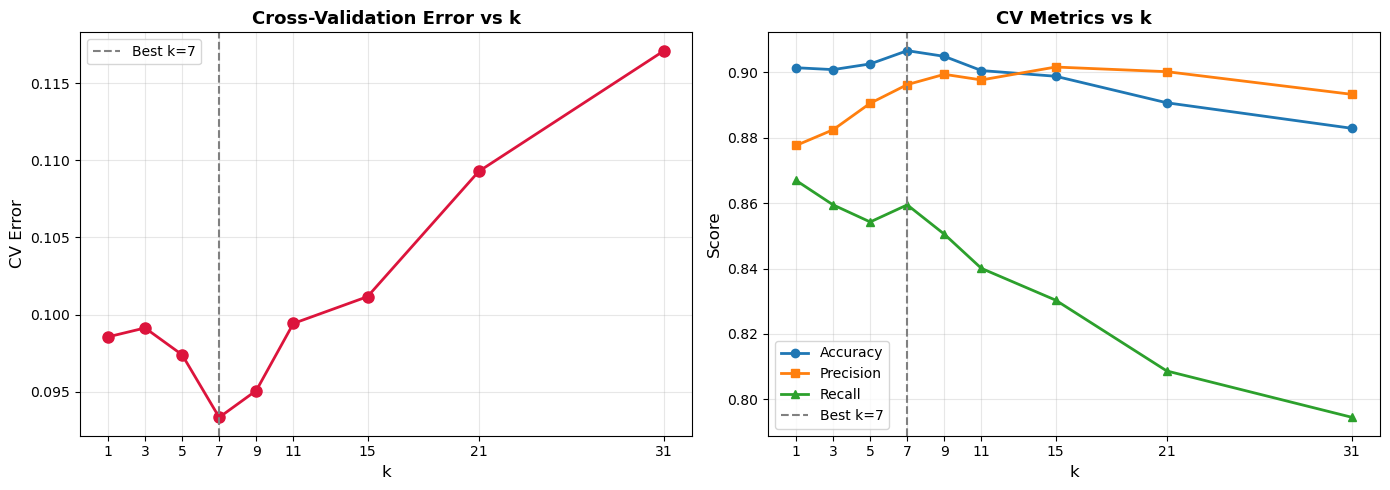

In [10]:
# kNN cross-validation

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv_results = []

print("kNN Cross-Validation")
print(f"{'k':<6} {'Accuracy':<12} {'Error':<12} {'Precision':<12} {'Recall':<12}")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    cv = cross_validate(knn, X_train, y_train, cv=5, scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall'
    })
    
    # metrics mean
    acc  = cv['test_accuracy'].mean()
    err  = 1 - acc
    prec = cv['test_precision'].mean()
    rec  = cv['test_recall'].mean()

    cv_results.append({
        'k': k, 
        'accuracy': acc, 
        'error': err,
        'precision': prec, 
        'recall': rec
    })
    
    print(f"{k:<6} {acc:<12.4f} {err:<12.4f} {prec:<12.4f} {rec:<12.4f}")

best = min(cv_results, key=lambda x: x['error'])
print(f"\n Best k = {best['k']} with CV Error = {best['error']:.4f} "
      f"(Accuracy = {best['accuracy']:.4f})")

# plot
errors     = [r['error']     for r in cv_results]
accuracies = [r['accuracy']  for r in cv_results]
precisions = [r['precision'] for r in cv_results]
recalls    = [r['recall']    for r in cv_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# cross-val error vs k
axes[0].plot(k_values, errors, marker='o', color='crimson', linewidth=2, markersize=8)
axes[0].axvline(best['k'], color='gray', linestyle='--', label=f"Best k={best['k']}")
axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('CV Error', fontsize=12)
axes[0].set_title('Cross-Validation Error vs k', fontsize=13, fontweight='bold')
axes[0].set_xticks(k_values)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CV mets vs k
axes[1].plot(k_values, accuracies, marker='o', label='Accuracy',  linewidth=2)
axes[1].plot(k_values, precisions, marker='s', label='Precision', linewidth=2)
axes[1].plot(k_values, recalls,    marker='^', label='Recall',    linewidth=2)
axes[1].axvline(best['k'], color='gray', linestyle='--', label=f"Best k={best['k']}")
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('CV Metrics vs k', fontsize=13, fontweight='bold')
axes[1].set_xticks(k_values)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

best_k = best['k']

classifiers = {
    'Logistic Regression': model,                
    'LDA': LinearDiscriminantAnalysis(),
    'kNN (k={})'.format(best_k): KNeighborsClassifier(n_neighbors=best_k)
}

classifiers['LDA'].fit(X_train, y_train)
classifiers['kNN (k={})'.format(best_k)].fit(X_train, y_train)

print("Classifier Comparison:")
print(f"{'Classifier':<24} {'Set':<8} {'Accuracy':<12} {'Error':<10} {'Precision':<12} {'Recall':<10}")

summary = []

# show/ print
for name, clf in classifiers.items():
    for label, X_set, y_set in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        y_pred_clf = clf.predict(X_set)
        acc  = accuracy_score(y_set, y_pred_clf)
        err  = 1 - acc
        prec = precision_score(y_set, y_pred_clf, zero_division=0)
        rec  = recall_score(y_set, y_pred_clf)

        summary.append({
            'Classifier': name, 
            'Set': label,
            'Accuracy': acc, 
            'Error': err,
            'Precision': prec, 
            'Recall': rec
        })

        print(f"{name:<24} {label:<8} {acc:<12.2f} {err:<10.2f} {prec:<12.2f} {rec:<10.2f}")
    print()

Classifier Comparison:
Classifier               Set      Accuracy     Error      Precision    Recall    
Logistic Regression      Train    0.93         0.07       0.92         0.88      
Logistic Regression      Test     0.92         0.08       0.94         0.87      

LDA                      Train    0.89         0.11       0.92         0.78      
LDA                      Test     0.89         0.11       0.93         0.78      

kNN (k=7)                Train    0.92         0.08       0.92         0.88      
kNN (k=7)                Test     0.90         0.10       0.91         0.84      



### Which model is performing best? Which one is performing worst? Write down some observations.

The logistic regression is performing the best with accuracy 93% and 92% for train and test sets, following behind is kNN with 92% and 90%, then LDA as the worst performing with both sets' accuracy being 89%. Recall for kNN is higher than LDA though, and kNN ties with logistic regression for training set recall at 0.88. Overall, the three models all exceend 89% in terms of accuracy.

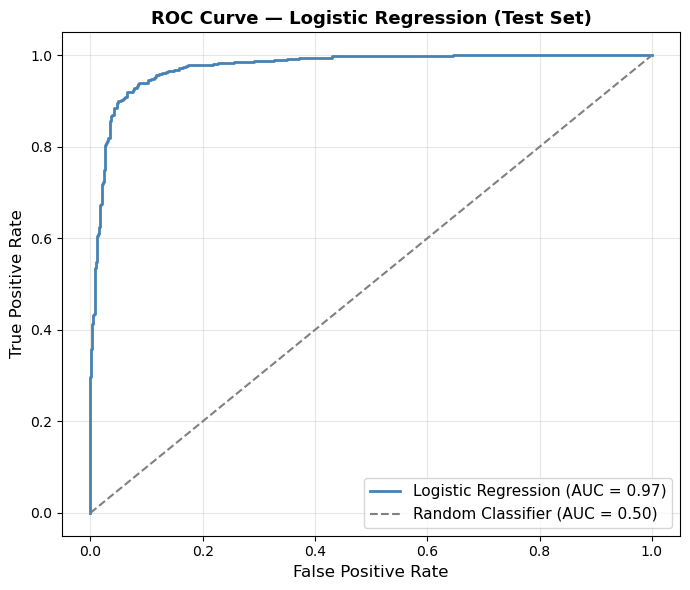

AUC = 0.97


In [12]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = model.predict_proba(X_test)[:, 1] 

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

#roc_df = pd.DataFrame({
#    'Threshold': thresholds,
#    'FPR':       fpr,
#    'TPR':       tpr
#})

#print(roc_df.to_string(index=False))

# plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1.5, label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression (Test Set)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC = {roc_auc:.2f}")

My ROC:
Threshold    FPR        TPR       
0.0          1.0000     1.0000    
0.1          0.3077     0.9874    
0.2          0.1524     0.9684    
0.3          0.0917     0.9389    
0.4          0.0636     0.9095    
0.5          0.0385     0.8674    
0.6          0.0340     0.8295    
0.7          0.0266     0.7874    
0.8          0.0222     0.7179    
0.9          0.0118     0.6000    
1.0          0.0000     0.0021    


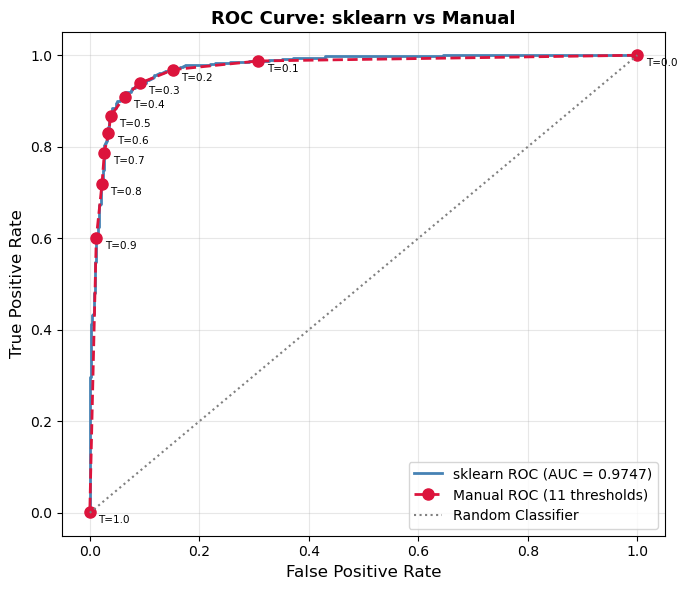

In [13]:
thresholds_manual = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

manual_fpr = []
manual_tpr = []

print("My ROC:")
print(f"{'Threshold':<12} {'FPR':<10} {'TPR':<10}")

for T in thresholds_manual:
    y_pred_T = (y_prob_lr >= T).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_T).ravel()

    # FPR = FP / (FP + TN)
    fpr_t = fp / (fp + tn)
                 
    # TPR = TP / (TP + FN)
    tpr_t = tp / (tp + fn) 
    
    manual_fpr.append(fpr_t)
    manual_tpr.append(tpr_t)
    
    print(f"{T:<12} {fpr_t:<10.4f} {tpr_t:<10.4f}")

# now plot
plt.figure(figsize=(7, 6))
         
# sklearn ROC smooth
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'sklearn ROC (AUC = {roc_auc:.4f})')

# manual ROC coarse
plt.plot(manual_fpr, manual_tpr, color='crimson', linewidth=2,
         linestyle='--', marker='o', markersize=8,
         label='Manual ROC (11 thresholds)')

# annotate each thresh point
for i, T in enumerate(thresholds_manual):
    plt.annotate(f'T={T}', (manual_fpr[i], manual_tpr[i]),
                 textcoords="offset points", xytext=(6, -8), fontsize=7.5)

# rand baseline
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1.5,
         label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve: sklearn vs Manual', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What are the differences and what changes can you make to get the two ROC curves to become more similar?

The curves are similar overall, the package version computed about 100+ more threshholds than my manual version which only computed 11 threshholds, meaning the package captured a lot more of the relationship than my manual one. i could usenp.unique which finds all the distinct/ unique values as the threshold set, which wiuld make the curve identical to the package version.

# *[C]* Problem 4: Cross validation (25 points)

In this problem, you will implement your own $k$-fold cross-validation algorithm and apply it to two linear classifiers (Logistic Regression
and LDA). Use the *SPAMBASE* dataset for this problem.

1. Implement $k$-fold cross-validation (CV) for training a model. The CV algorithm consists of the following steps:
    1. Divide the entire data into $k$ partitions of equal size.
    2. Run $k$ experiments. In each experiment $i \in \{1,\dots,k\}$, train on $k-1$ partitions and test on the validation set
    (partition $i$).
    3. Record the validation error for each experiment.
    4. Compute and print the **average validation error** across all $k$ experiments.
2. Run the CV experiment for logistic regression and LDA for $k \in \{5,10\}$. You can use a package for training the logistic
regression and LDA models. Print for each model the average validation error for each value of $k$.
3. Which model performs better? Compare the results.

In [14]:
# my k fold cross val
def k_fold_cross_v(X, y, model_class, model_params, k=5):
    n_samples = len(y)
    fold_size = n_samples // k

    indices = np.random.seed(42)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    folds = []
    for i in range(k):
        start = 1 * fold_size
        end = start + fold_size
        folds.append(indices[start:end])

    fold_err = []

    for i in range(k):
        val_idx = folds[i]

        train_idx =  np.concatenate([folds[j] for j in range(k) if j != i])

        X_tr, y_tr = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx],  y[val_idx]

        clf = model_class(**model_params)
        clf.fit(X_tr, y_tr)

        y_val_pred = clf.predict(X_val)
        val_error  = 1 - accuracy_score(y_val, y_val_pred)
        fold_err.append(val_error)

        print(f"  Fold {i+1}/{k} — Val Error: {val_error:.2f}")

    avg_error = np.mean(fold_err)
    print(f"  Average Validation Error: {avg_error:.4f}  "
          f"(Avg Accuracy: {1-avg_error:.4f})\n")

    return fold_err, avg_error

X_full = np.vstack([X_train, X_test])
y_full = np.concatenate([y_train, y_test])

k = 5

print("Logistic Regression — {}-Fold CV".format(k))

lr_errors, lr_avg = k_fold_cross_v(
    X_full, y_full,
    model_class=LogisticRegression,
    model_params={'max_iter': 1000, 'random_state': 42},
    k=k
)

print("LDA — {}-Fold CV".format(k))
lda_errors, lda_avg = k_fold_cross_v(
    X_full, y_full,
    model_class=LinearDiscriminantAnalysis,
    model_params={},
    k=k
)

print("Summary:")
print(f"{'Classifier':<25} {'Avg Val Error':<16} {'Avg Val Accuracy'}")
print(f"{'Logistic Regression':<25} {lr_avg:<16.2f} {1-lr_avg:.2f}")
print(f"{'LDA':<25} {lda_avg:<16.2f} {1-lda_avg:.2f}")

Logistic Regression — 5-Fold CV
  Fold 1/5 — Val Error: 0.07
  Fold 2/5 — Val Error: 0.07
  Fold 3/5 — Val Error: 0.07
  Fold 4/5 — Val Error: 0.07
  Fold 5/5 — Val Error: 0.07
  Average Validation Error: 0.0663  (Avg Accuracy: 0.9337)

LDA — 5-Fold CV
  Fold 1/5 — Val Error: 0.10
  Fold 2/5 — Val Error: 0.10
  Fold 3/5 — Val Error: 0.10
  Fold 4/5 — Val Error: 0.10
  Fold 5/5 — Val Error: 0.10
  Average Validation Error: 0.1011  (Avg Accuracy: 0.8989)

Summary:
Classifier                Avg Val Error    Avg Val Accuracy
Logistic Regression       0.07             0.93
LDA                       0.10             0.90


  5-Fold Cross Validation

  Logistic Regression:
  Fold 1/5 — Val Error: 0.07
  Fold 2/5 — Val Error: 0.07
  Fold 3/5 — Val Error: 0.07
  Fold 4/5 — Val Error: 0.07
  Fold 5/5 — Val Error: 0.07
  Average Validation Error: 0.0663  (Avg Accuracy: 0.9337)


  LDA:
  Fold 1/5 — Val Error: 0.10
  Fold 2/5 — Val Error: 0.10
  Fold 3/5 — Val Error: 0.10
  Fold 4/5 — Val Error: 0.10
  Fold 5/5 — Val Error: 0.10
  Average Validation Error: 0.1011  (Avg Accuracy: 0.8989)

  10-Fold Cross Validation

  Logistic Regression:
  Fold 1/10 — Val Error: 0.03
  Fold 2/10 — Val Error: 0.03
  Fold 3/10 — Val Error: 0.03
  Fold 4/10 — Val Error: 0.03
  Fold 5/10 — Val Error: 0.03
  Fold 6/10 — Val Error: 0.03
  Fold 7/10 — Val Error: 0.03
  Fold 8/10 — Val Error: 0.03
  Fold 9/10 — Val Error: 0.03
  Fold 10/10 — Val Error: 0.03
  Average Validation Error: 0.0326  (Avg Accuracy: 0.9674)


  LDA:
  Fold 1/10 — Val Error: 0.08
  Fold 2/10 — Val Error: 0.08
  Fold 3/10 — Val Error: 0.08
  Fold 4/10 — Val Erro

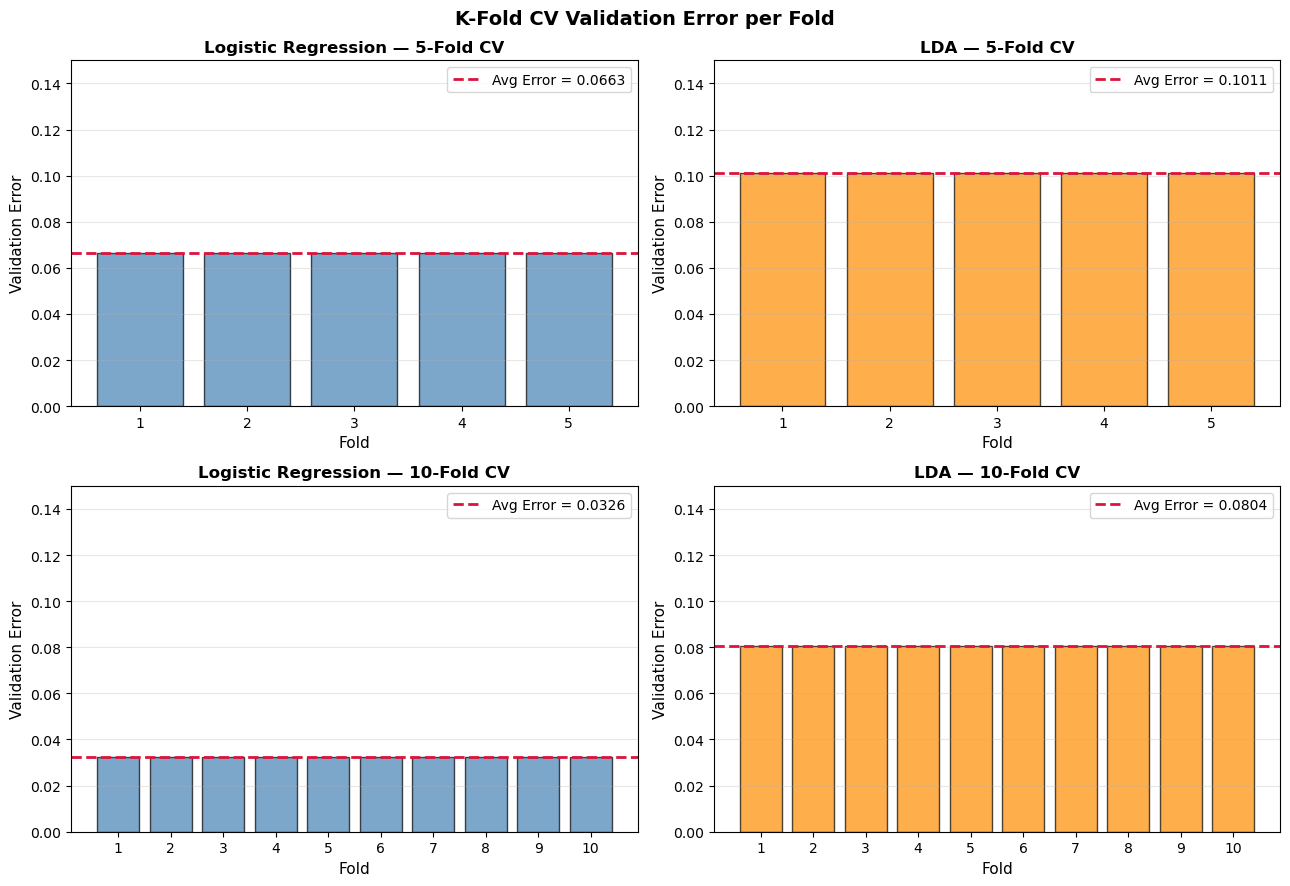

In [15]:
k_values = [5, 10]
models = {
    'Logistic Regression': (LogisticRegression, {'max_iter': 1000, 'random_state': 42}),
    'LDA': (LinearDiscriminantAnalysis, {})
}

results = {}

for k in k_values:
    print(f"  {k}-Fold Cross Validation")
    
    for model_name, (model_class, model_params) in models.items():
        print(f"\n  {model_name}:")
        fold_errors, avg_error = k_fold_cross_v(
            X_full, y_full,
            model_class=model_class,
            model_params=model_params,
            k=k
        )
        results[(model_name, k)] = {
            'fold_errors': fold_errors,
            'avg_error':   avg_error
        }
print("Avg Validation Error:")
print(f"{'Classifier':<25} {'k=5 Error':<14} {'k=5 Acc':<14} {'k=10 Error':<14} {'k=10 Acc'}")

for model_name in models:
    e5  = results[(model_name, 5)]['avg_error']
    e10 = results[(model_name, 10)]['avg_error']
    print(f"{model_name:<25} {e5:<14.2f} {1-e5:<14.2f} {e10:<14.2f} {1-e10:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {'Logistic Regression': 'steelblue', 'LDA': 'darkorange'}

for row, k in enumerate(k_values):
    for col, model_name in enumerate(models):
        ax = axes[row][col]
        fold_errors = results[(model_name, k)]['fold_errors']
        avg_error   = results[(model_name, k)]['avg_error']

        ax.bar(range(1, k+1), fold_errors,
               color=colors[model_name], alpha=0.7, edgecolor='black')
        ax.axhline(avg_error, color='crimson', linestyle='--',
                   linewidth=2, label=f'Avg Error = {avg_error:.4f}')

        ax.set_title(f'{model_name} — {k}-Fold CV',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Fold', fontsize=11)
        ax.set_ylabel('Validation Error', fontsize=11)
        ax.set_xticks(range(1, k+1))
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 0.15)

plt.suptitle('K-Fold CV Validation Error per Fold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Which model performs better? Compare the results.

My cross validation and the package cross validation performed exactly the same. Between the logistic regression and the LDA, the logistic regression consistantly outperforms the LDA in either implementation by 3% to 5% depending on if k = 5 or 10. Both models improve when k increases to 10, with the logistic regression improving about 4% more from when k=5, while LDA only improved about 2% more in accuracy.

## Helpful resources 
Don't forget to cite websites which helped you solve a problem in a unique way.  You can do this in markdown near the code or with a simple one-line comment inside the code cell, or you can list them below. 

You do not need to cite the official python documentation.


https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/
https://www.geeksforgeeks.org/machine-learning/derivative-of-the-sigmoid-function/
https://www.geeksforgeeks.org/machine-learning/implementation-of-logistic-regression-from-scratch-using-python/
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html
https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html
https://medium.com/@avijit.bhattacharjee1996/implementing-k-fold-cross-validation-from-scratch-in-python-ae413b41c80d
